# Bias-reduced sparse SGD on one-hot Criteo

This notebook runs `bias_reduced_sgd` — Ghazi, Guzmán, Kamath, Kumar and
Manurangsi, *Differentially Private Optimization with Sparse Gradients*,
NeurIPS 2024 ([arXiv:2404.10881](https://arxiv.org/abs/2404.10881)),
Algorithms 3 and 4 — by itself on one-hot Criteo, and sweeps it over the
knobs it has. There are only three: `max_scale`, the clipping norm, and the
learning rate. The algorithm takes no step count and no noise multiplier —
the first is an output of the privacy filter and the second is derived from
the budget — so a budget and those three numbers are the whole configuration.

The dataset is the one the method exists for. `load_criteo_one_hot`
(ADR-0020) encodes all 39 columns at their native cardinalities into 551,947
coordinates and hands back the 39 indices each row occupies rather than the
row, which makes the per-example gradient exactly 40-sparse by construction —
assumption (A.7) of the paper, held rather than hoped for.

**The result is negative, and the sweep's job turns out to be establishing
that the budget is at fault rather than the tuning.** At ε = 1 — the largest
budget the analysis admits — every inner release runs at a noise multiplier
of 250, and none of the twenty-one configurations below moves the model off
its initialization: they score its log-loss of 0.700 and, at best, its PR-AUC
of 0.264, both worse than a constant predictor. The same loop with the noise
switched off reaches PR-AUC 0.3187 on `x̄`, the output rule every table here
reports, and 0.3623 on its last iterate. Section 8 measures the ratio that
decides it — one debiased estimate carries an error 828 times the length of
the gradient it estimates, which needs 685,000 steps to average out, and the
filter admits 94,000.

One consequence of that flatness is worth having in view from the start.
Sweeping is selecting, and selecting needs differences that are larger than
the noise; here they are not, and the winner section 6 names is the worst
ranker of its own clip column. Section 6 says so where it happens, section 7
says so again where the configuration is frozen, and the closing says what it
means for a comparison notebook that inherits the frozen point.

In [1]:
import os

# The sweeps below run configurations concurrently on one device, and the
# pool is sized against what the allocator will hand out (section 3). JAX
# reads this once, at import, and takes 75% of the device without it.
os.environ.setdefault("XLA_PYTHON_CLIENT_MEM_FRACTION", "0.8")

import time
from concurrent.futures import ThreadPoolExecutor
from functools import partial
from typing import NamedTuple

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from dimma.accounting import bias_reduced_sgd as accounting
from dimma.algorithms.bias_reduced_sgd import estimators
from dimma.algorithms.bias_reduced_sgd import step as brs_step
from dimma.algorithms.bias_reduced_sgd import train as bias_reduced_sgd
from dimma.core import clipping, gradients, updates
from dimma.core.sampling import dyadic
from dimma.datasets.criteo import load_criteo_one_hot
from dimma.metrics.calibration import (
    calibration_ratio,
    expected_calibration_error,
)
from dimma.metrics.operating_point import Confusion, confusion_at
from dimma.metrics.ranking import pr_curve
from dimma.metrics.scoring import log_loss, normalized_entropy
from dimma.models.logreg import forward_sparse, init_params

DEVICE = "gpu" if any(d.platform == "gpu" for d in jax.devices()) else "cpu"
print(f"jax devices: {jax.devices()}  ->  DEVICE = {DEVICE!r}")

# Notebook 01's palette, unchanged so that two tuning notebooks read the same
# way. Blue carries the private run, orange the noiseless control, aqua a
# third series where one is needed. The three clear the colour-vision and
# normal-vision separation floors as a set; aqua sits under 3:1 against
# white, which is why every point it draws is also printed as a table above
# the figure.
INK, MUTED, SURFACE = "#0b0b0b", "#52514e", "#fcfcfb"
PRIVATE_C, CONTROL_C, THIRD_C = "#2a78d6", "#eb6834", "#1baf7a"

jax devices: [CudaDevice(id=0)]  ->  DEVICE = 'gpu'


In [2]:
TARGET_EPSILON = 1.0
TARGET_DELTA = 1e-12

MAX_SCALES = (7, 8, 9, 10, 11, 12)
SCALE_SWEEP_STEPS = 3_000

CLIP_NORMS = (1.0, 2.0, 4.0)
LEARNING_RATES = (1e-4, 1e-3, 1e-2)
GRID_STEPS = 3_000

STEP_GRID = (200, 400, 800, 1_600, 3_200, 6_400)

# Where the first sweep holds the two axes it is not sweeping. The clip norm
# sits just under the median per-sample gradient norm section 4 measures at
# the initialization, so it binds on most examples without discarding most of
# each gradient; the learning rate is the middle of the bracket section 6
# sweeps.
PROVISIONAL_CLIP_NORM = 2.0
PROVISIONAL_LEARNING_RATE = 1e-3

# The paper's radius mapping, `clip_norm * sqrt(s)`. Every row of this
# encoding stores 39 feature entries, and the bias is the fortieth
# coordinate of every per-sample gradient, so `s` is 40 exactly and not a
# maximum read off the data (ADR-0020).
SPARSITY = 40

SEED = 0
FEATURE_NORM_BOUND = None
PROBE_DRAWS = 512

## 1. Data

Criteo click-through data with all 39 features one-hot encoded at the
cardinalities the training split gives them. The return is a
`SparseTabularSplit`, not a matrix: 39 indices and 39 values a row, over a
feature space 551,947 wide whose dense form would be 2.2 TB. The split is
deterministic given `seed` and `test_fraction` and is cut by the same code as
every other Criteo mode, so these are the same held-out rows notebook 01 and
notebook 02 scored on.

In [3]:
split = load_criteo_one_hot(preprocess=True, download=False, seed=SEED,
                            device=DEVICE,
                            feature_norm_bound=FEATURE_NORM_BOUND
                            )

n_train, stored_per_row = split.idx_train.shape
n_features = split.num_features
base_rate = float(split.y_test.mean())
print(f"train {split.idx_train.shape}   test {split.idx_test.shape}")
print(f"{n_features:,} feature coordinates, {stored_per_row} stored a row")
print(f"label base rate: {float(split.y_train.mean()):.4f} train, "
      f"{base_rate:.4f} test")
print(f"PR-AUC floor (a random ranking scores the base rate): {base_rate:.4f}")

criteo: 39 features as index/value pairs. I1-I13 at indices 0-12: NaN filled with the train-split median, clipped below at 0, then log1p — the fill and the clip are no-ops on stored values that carry neither NaN nor negatives, and log1p acts on [0, 1]. C1-C26 one-hot at their native train-split cardinalities, each column holding its own block of the index space and one slot reserved for IDs unseen in the training split, so every row carries exactly 39 entries whatever it holds. Not standardized: centring a one-hot column fills it, and the sparsity is the point.


train (800000, 39)   test (200000, 39)
551,947 feature coordinates, 39 stored a row
label base rate: 0.2510 train, 0.2520 test
PR-AUC floor (a random ranking scores the base rate): 0.2520


A dimma per-sample loss is `(params, x_single, y_single) -> scalar` and a
training loop slices its `x` along one leading axis, so the two arrays a
sparse row comes in have to travel as one. They are concatenated: the first
39 columns are the indices, the last 39 the values. Indices go through
float32 exactly — the widest is 551,946, well inside the 16,777,216 where
float32 stops counting by ones — and the assertion below is what says so
rather than a comment claiming it.

The loss is `dimma.models.losses.per_sample_bce_loss` over
`forward_sparse` instead of `forward`: the same model and the same logit,
computed from the pair rather than from the dense row it implies. It is
written here rather than imported because the package's version composes with
the dense forward, and `softplus(z) - z*y` is the same overflow-safe
rearrangement the package uses.

In [4]:
X_TRAIN = jnp.concatenate(
    [split.idx_train.astype(jnp.float32), split.val_train], axis=1
)
assert (np.asarray(X_TRAIN[:, :stored_per_row]).astype(np.int64)
        == np.asarray(split.idx_train)).all(), "index round-trip is not exact"


def per_sample_sparse_bce(params, packed, y):
    """BCE for one example held as concatenated indices and values."""
    idx = packed[:stored_per_row].astype(jnp.int32)
    val = packed[stored_per_row:]
    logit = forward_sparse(params, idx, val)
    return jax.nn.softplus(logit) - logit * y


print(f"packed training features {X_TRAIN.shape} {X_TRAIN.dtype}, "
      f"{X_TRAIN.nbytes / 1e6:.0f} MB on {DEVICE}")

packed training features (800000, 78) float32, 250 MB on gpu


## 2. The budget, and the length the filter chooses

Two numbers are the whole privacy configuration, and neither of them is a
step count or a noise multiplier.

**ε = 1**, because the algorithm refuses anything larger: Lemma 5.3's
amplification is stated for ε ≤ 1, and above it the per-step price the
accountant charges would be an under-estimate rather than a bound. This is
not a budget chosen for utility. It is the largest one the analysis covers.

**δ = 1e-12**, because the package docstring's fourth precondition asks for δ
below `1 / n ** 2`, which at n = 800,000 is 1.56e-12. That precondition buys
Lemma 5.5's stopping-time bound and nothing else — above it the privacy still
holds and only the bound on how long the run lasts is lost — but the length
of the run is the thing this section is about, so the notebook pays for it.

That is a departure from the operating point issue #44 anticipated, and the
price of it belongs in the open. The ticket quoted δ = 1e-3, where the
multiplier is 142; the notebook runs at 250, which is **1.8 times as much
noise on every release**. The precondition wins the argument because a run
whose step count is unbounded is a run whose negative result could always be
answered with "it needed longer", and section 8's whole argument is a
step-count argument. But it does mean the negative result below is stated
under a harsher setting than the ticket expected, and that a reader who
wanted the ticket's δ should expect the same shape of answer with a smaller
margin rather than a different answer — the closing puts a number on how much
smaller. All three points are printed below rather than described.

From those two, `inner_noise_multiplier` fixes what every inner mean release
runs at, for the whole run and every slot in it: `32 sqrt(2 ln(20/δ)) / ε`.
The budget's journey inward is Algorithm 4 handing Algorithm 3 `(ε/8, δ/4)`,
Algorithm 3 splitting that four ways, and Algorithm 1 answering a slot — the
clipping norm and the batch size cancel out of the ratio, which is why one
dimensionless number serves a batch of 4,096 and a batch of one alike.

In [5]:
multiplier = accounting.inner_noise_multiplier(
    target_epsilon=TARGET_EPSILON, target_delta=TARGET_DELTA
)
holds = "holds" if TARGET_DELTA < 1 / n_train ** 2 else "fails"
print(f"1 / n ** 2 = {1 / n_train ** 2:.3e}, and delta = "
      f"{TARGET_DELTA:.0e}  ->  precondition {holds}\n")
print(f"{'delta':>8} {'multiplier':>12}   what it is")
for delta, note in ((TARGET_DELTA, "this notebook; below 1 / n ** 2"),
                    (1e-6, "notebook 01's, and above 1 / n ** 2"),
                    (1e-3, "the figure issue #44 anticipated")):
    at_delta = accounting.inner_noise_multiplier(
        target_epsilon=1.0, target_delta=delta)
    print(f"{delta:>8.0e} {at_delta:>12.1f}   {note}")

1 / n ** 2 = 1.563e-12, and delta = 1e-12  ->  precondition holds

   delta   multiplier   what it is
   1e-12        250.4   this notebook; below 1 / n ** 2
   1e-06        185.6   notebook 01's, and above 1 / n ** 2
   1e-03        142.4   the figure issue #44 anticipated


The run's length is an output. Each step draws a scale `N` from the public
coin, which fixes a price `(3 · 2^(N+1) + 1)(ε, δ) / 16n` before any data is
touched, and the filter admits the step only while both arms hold — the
ε arm through advanced composition, the δ arm as a plain sum against δ/4.

Which arm binds is worth knowing, because they say different things. The
δ arm is the one that stops these runs, and it gives `T ≈ 4n / (3M + 4)`
independently of the budget: **a larger ε buys quieter steps, never more of
them.** The ε arm sits two to three orders of magnitude further out.

In [6]:
class FilterLength(NamedTuple):
    """Steps each arm of Theorem A.4's stopping rule would admit."""

    epsilon_arm: float
    """Advanced composition over the per-step epsilons."""
    delta_arm: float
    """The plain sum of per-step deltas against delta / 4."""


def mean_batch(max_scale):
    """The batch size averaged over TGeom(max_scale).

    Not the divisor a step uses -- that is the exact size its own coin
    fixed -- but what the ladder costs on average.
    """
    probabilities = dyadic.scale_probabilities(max_scale)
    sizes = 2.0 ** (np.arange(max_scale + 1) + 1)
    return float(probabilities @ sizes)


def filter_length(max_scale):
    """Steps each arm of the filter would admit, in expectation.

    The per-step price depends only on the coin, so both arms can be
    solved for the number of steps whose *expected* cost exhausts them.
    """
    probabilities = dyadic.scale_probabilities(max_scale)
    costs = np.array([
        accounting.step_cost(scale=scale, n=n_train,
                             target_epsilon=TARGET_EPSILON,
                             target_delta=TARGET_DELTA)
        for scale in range(max_scale + 1)
    ])
    # sqrt(2 ln(4/delta) S) + S/2 = eps/2 at S = sum of squared epsilons.
    root = np.sqrt(2 * np.log(4 / TARGET_DELTA))
    budget = (np.sqrt(root ** 2 + TARGET_EPSILON) - root) ** 2
    return FilterLength(
        epsilon_arm=budget / float(probabilities @ costs[:, 0] ** 2),
        delta_arm=(TARGET_DELTA / 4) / float(probabilities @ costs[:, 1]),
    )


print(f"the ladder this training set carries: max_scale up to "
      f"{dyadic.max_scale(n_train)}, a largest batch of "
      f"{1 << (dyadic.max_scale(n_train) + 1):,}\n")
print(f"{'max_scale':>9} {'mean batch':>11} {'largest':>9} "
      f"{'T (delta arm)':>14} {'T (eps arm)':>14} {'4n/(3M+4)':>11}")
for max_scale in MAX_SCALES:
    admits = filter_length(max_scale)
    print(f"{max_scale:>9} {mean_batch(max_scale):>11.2f} "
          f"{1 << (max_scale + 1):>9,} "
          f"{admits.delta_arm:>14,.0f} "
          f"{admits.epsilon_arm:>14,.0f} "
          f"{4 * n_train / (3 * max_scale + 4):>11,.0f}")

the ladder this training set carries: max_scale up to 18, a largest batch of 524,288

max_scale  mean batch   largest  T (delta arm)    T (eps arm)   4n/(3M+4)
        7        8.03       256        127,520    150,255,782     128,000
        8        9.02       512        114,070     75,478,534     114,286
        9       10.01     1,024        103,128     37,839,574     103,226
       10       11.01     2,048         94,073     18,948,007      94,118
       11       12.00     4,096         86,466      9,481,840      86,486
       12       13.00     8,192         79,990      4,743,074      80,000


## 3. The ladder, what a step allocates, and the wall clock

`max_scale` is `M`, the top of the dyadic ladder, and the paper's value is
`floor(log2 n) - 1` — 18 here, for a largest batch of 524,288. That batch
cannot run. Per-example gradients are dense: `jax.grad` of a logit that
gathers 40 coordinates still returns a `(551,947,)` row per example, so a
step at the top of the ladder allocates `2^(M+1) × 551,947` float32, which at
M = 18 is 1.2 TB. The sparsity buys the data and the forward pass; it does
not buy the gradient buffer (ADR-0020's closing consequence).

Lowering `max_scale` is the answer, and it is not a truncation. It runs
`TGeom(M')` instead of `TGeom(M)` — a different law over the scale, whose
debias weights, per-step price and bias bound all follow along — so each
value in the sweep below is a *different mechanism*, analysable as itself.
That is what makes it the natural first tuning axis rather than a memory
setting: ADR-0007's principle, that a draw is never reshaped to fit a memory
bound, is respected by changing the law instead of the batch.

The table is what each value costs, and the figure puts it beside what each
value buys.

In [7]:
BYTES_PER_FLOAT32 = 4


def top_of_ladder_bytes(max_scale):
    """The dense per-example gradient block a step at the top allocates."""
    return (1 << (max_scale + 1)) * n_features * BYTES_PER_FLOAT32


limit = jax.devices()[0].memory_stats()["bytes_limit"]
print(f"the allocator will hand out {limit / 1e9:.1f} GB on this device\n")
print(f"{'max_scale':>9} {'largest batch':>14} {'gradient block':>15}")
for max_scale in (*MAX_SCALES, dyadic.max_scale(n_train)):
    block = top_of_ladder_bytes(max_scale)
    fits = "" if block < limit else "   does not fit"
    print(f"{max_scale:>9} {1 << (max_scale + 1):>14,} "
          f"{block / 1e9:>13.2f} GB{fits}")

the allocator will hand out 40.7 GB on this device

max_scale  largest batch  gradient block
        7            256          0.57 GB
        8            512          1.13 GB
        9          1,024          2.26 GB
       10          2,048          4.52 GB
       11          4,096          9.04 GB
       12          8,192         18.09 GB
       18        524,288       1157.52 GB   does not fit


Both panels are functions of `max_scale` alone, computed above, and neither
is a measurement of a run. They are drawn together because the tuning
question is the trade between them: a taller ladder makes the rare large
batch larger, which is where the estimate's variance comes down, and it
shortens the run, because a larger expected batch is charged more per step.

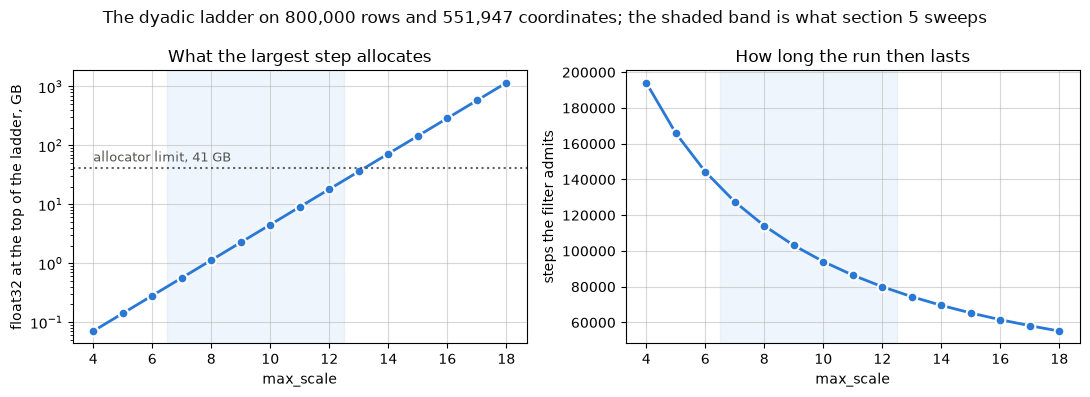

In [8]:
ladder = list(range(4, dyadic.max_scale(n_train) + 1))
blocks = [top_of_ladder_bytes(m) / 1e9 for m in ladder]
lengths = [filter_length(m).delta_arm for m in ladder]

fig, (left, right) = plt.subplots(1, 2, figsize=(11, 4))

left.plot(ladder, blocks, marker="o", markersize=7, linewidth=2,
          color=PRIVATE_C, markeredgecolor=SURFACE, markeredgewidth=1.5)
left.axhline(limit / 1e9, color=MUTED, linestyle=":", alpha=0.9)
left.annotate(f"allocator limit, {limit / 1e9:.0f} GB",
              xy=(ladder[0], limit / 1e9), xytext=(0, 5),
              textcoords="offset points", color=MUTED, fontsize=9)
left.set_yscale("log")
left.set_ylabel("float32 at the top of the ladder, GB")
left.set_title("What the largest step allocates")

right.plot(ladder, lengths, marker="o", markersize=7, linewidth=2,
           color=PRIVATE_C, markeredgecolor=SURFACE, markeredgewidth=1.5)
right.set_ylabel("steps the filter admits")
right.set_title("How long the run then lasts")

for axis in (left, right):
    axis.axvspan(MAX_SCALES[0] - 0.5, MAX_SCALES[-1] + 0.5, color=PRIVATE_C,
                 alpha=0.07)
    axis.set_xlabel("max_scale")
    axis.grid(alpha=0.5)

fig.suptitle("The dyadic ladder on 800,000 rows and 551,947 coordinates; "
             "the shaded band is what section 5 sweeps", color=INK)
fig.tight_layout()
plt.show()

**The wall clock, and how it is bought.** A step costs about 37 ms here, and
almost none of that is the batch: the mean batch is a dozen examples, while
every step perturbs and projects four vectors of 551,947 coordinates and
brings them back to the host in float64. The cost is therefore nearly flat in
the scale, and the 80,000 to 128,000 steps the filter would admit across this
ladder are about an hour a configuration. This notebook's whole execution has
twenty minutes.

Two things buy that, and neither of them touches the mechanism. The first is
`max_steps`, which is a wall-clock guard and **not** a privacy parameter:
stopping early is strictly less access to the data, so the
`(ε, δ)` guarantee is untouched and what is lost is Section 5.3.1's *lower*
bound on the stopping time, and with it the accuracy theorem. Every run below
is capped, and the caps are in the configuration block.

The second is that configurations are independent, so they run concurrently
in one process on one device. Threads change wall-clock and nothing else —
every run carries its own two seeds, so no result can depend on which of them
was in flight when. What the pool size must respect is memory: each worker's
largest step allocates one dense block from the table above, and several
workers can reach their top scale at the same moment. The pool is sized so
that even that coincidence fits, and each sweep prints how many ran at once
and what the wall clock was.

In [9]:
HEADROOM_BYTES = 2 * 1024 ** 3


def pool_size(scales):
    """Workers whose simultaneous worst case still fits on the device."""
    stats = jax.devices()[0].memory_stats()
    free = stats["bytes_limit"] - stats["bytes_in_use"] - HEADROOM_BYTES
    total, workers = 0, 0
    for block in sorted((top_of_ladder_bytes(s) for s in scales),
                        reverse=True):
        if total + block > free:
            break
        total, workers = total + block, workers + 1
    return max(1, workers)


def concurrently(jobs):
    """Run one configuration per thread and return the outcomes in order."""
    workers = pool_size([job["max_scale"] for job in jobs])
    t0 = time.time()
    with ThreadPoolExecutor(max_workers=workers) as pool:
        outcomes = list(pool.map(lambda job: run(**job), jobs))
    print(f"{len(jobs)} configurations, {workers} at a time, "
          f"{time.time() - t0:.0f}s on {DEVICE}\n")
    return outcomes

## 4. Training, and the operating point

`train` takes the same first seven positional arguments as `dp_sgd.train`, so
the model and the loss are unchanged from a DP-SGD run and only the keywords
after them differ. Three of those differences matter here: there is no
`steps`, because `T` is an output; there is no noise multiplier, because the
budget fixes it; and `estimator` is a factory rather than a scale, which is
the seam section 7's control reaches through.

It returns three parameter sets. **`average_params` is what the tables below
report** — `x̄`, the mean of `x⁰ … x^T`, which is the output rule Theorem
5.6's excess-risk bound is stated for and the right one for a convex
objective like this. `final_params` is carried alongside because no bound
covers it and it is worth seeing what it does anyway.

**The threshold.** At a 25% base rate a calibrated model rarely emits
`p > 0.5`, so that cut would report the base rate rather than the classifier.
Every confusion matrix below flags a record when the model puts it at or
above the **training-split base rate** — one number, fixed before any run,
and a training-split statistic rather than a further read of the test labels.

**The five numbers** are notebook 01's, for the same reasons, and both the
ranking and the confusion matrix now come from `dimma.metrics` rather than
from a cell: log-loss, normalized entropy, calibration ratio, ECE at 15
equal-mass bins, and PR-AUC floored at the base rate.

In [10]:
Y_TEST = np.asarray(split.y_test, dtype=np.float64)
THRESHOLD = float(split.y_train.mean())
N_BINS = 15
print(f"decision threshold p >= {THRESHOLD:.4f}")

_score = jax.jit(jax.vmap(forward_sparse, in_axes=(None, 0, 0)))


class Eval(NamedTuple):
    """Everything one parameter set is scored on."""

    loss: float
    ne: float
    ece: float
    cal_ratio: float
    pr_auc: float
    confusion: Confusion
    """Kept as the named value `confusion_at` returns: the four counts
    unpack in scikit-learn's ravelled order, which is the transposition
    its docstring warns about, so nothing here reads them by position."""


class Outcome(NamedTuple):
    """One run: both output rules scored, and what the filter spent."""

    average: Eval
    """`x-bar`, the convex output rule, and what every table reports."""
    final: Eval
    """`x^{T+1}`, which no bound covers."""
    steps: int
    epsilon: float
    """The accountant's number for the transcript that actually ran."""


def evaluate(params):
    """Score one parameter set on the test split.

    Parameters come back as host float64; the model runs in float32, and
    the conversion is here rather than in the loop so that what is scored
    is what a caller would deploy.
    """
    float32 = jax.tree.map(lambda leaf: jnp.asarray(leaf, jnp.float32), params)
    logits = _score(float32, split.idx_test, split.val_test)
    probs = np.asarray(jax.nn.sigmoid(logits), dtype=np.float64)
    return Eval(
        loss=log_loss(probs, Y_TEST),
        ne=normalized_entropy(probs, Y_TEST),
        ece=expected_calibration_error(probs, Y_TEST, n_bins=N_BINS),
        cal_ratio=calibration_ratio(probs, Y_TEST),
        pr_auc=pr_curve(probs, Y_TEST).average_precision,
        confusion=confusion_at(probs, Y_TEST, THRESHOLD),
    )


def rates(confusion):
    """Precision and recall (TPR) from a `Confusion`, read by name."""
    flagged = confusion.true_positives + confusion.false_positives
    clicks = confusion.true_positives + confusion.false_negatives
    precision = (confusion.true_positives / flagged if flagged
                 else float("nan"))
    recall = confusion.true_positives / clicks if clicks else float("nan")
    return precision, recall


def show_confusion(confusion, title):
    """The 2x2 as a table -- four numbers do not need a chart."""
    precision, recall = rates(confusion)
    print(f"{title}")
    print(f"                 predicted no    predicted click")
    print(f"  actual no      {confusion.true_negatives:>12,}    "
          f"{confusion.false_positives:>15,}")
    print(f"  actual click   {confusion.false_negatives:>12,}    "
          f"{confusion.true_positives:>15,}")
    print(f"  precision {precision:.4f}   recall {recall:.4f}   "
          f"(at threshold {THRESHOLD:.4f})")


def run(*, max_scale, clip_norm, learning_rate, max_steps,
        estimator=estimators.projection_estimator, seed=SEED):
    """One complete bias-reduced run, from a fresh initialization."""
    params = init_params(jax.random.key(0), n_features)
    trained = bias_reduced_sgd.train(
        per_sample_sparse_bce, params, updates.sgd(learning_rate),
        X_TRAIN, split.y_train,
        jax.random.key(seed), np.random.default_rng(seed),
        target_epsilon=TARGET_EPSILON, target_delta=TARGET_DELTA,
        clip_norm=clip_norm, radius=clip_norm * np.sqrt(SPARSITY),
        estimator=estimator, max_scale=max_scale, max_steps=max_steps,
    )
    return Outcome(
        average=evaluate(trained.average_params),
        final=evaluate(trained.final_params),
        steps=trained.steps,
        epsilon=accounting.epsilon(trained.spent, target_delta=TARGET_DELTA),
    )

decision threshold p >= 0.2510


Two references every row below is read against. The **constant predictor**
ignores the features and always emits the training base rate; anything
scoring worse than it has learned something worse than nothing, however good
its ranking. **The initialization** is the other one, and on this notebook it
is the more important of the two: a private run that scores it has not moved.

The clipping norm's bracket is chosen against the third number here, the
per-sample gradient norm the clipping acts on. Far above it clipping does
nothing; far below it every per-sample gradient is rescaled to the same
length, which is a different update direction with no reason to reach the
logistic optimum.

In [11]:
CONST_PROBS = np.full_like(Y_TEST, THRESHOLD)
CONST = Eval(
    loss=log_loss(CONST_PROBS, Y_TEST),
    ne=normalized_entropy(CONST_PROBS, Y_TEST),
    ece=expected_calibration_error(CONST_PROBS, Y_TEST, n_bins=N_BINS),
    cal_ratio=calibration_ratio(CONST_PROBS, Y_TEST),
    pr_auc=base_rate,
    confusion=confusion_at(CONST_PROBS, Y_TEST, THRESHOLD),
)
START = init_params(jax.random.key(0), n_features)
BEFORE = evaluate(START)

COLUMNS = f"{'log-loss':>9} {'NE':>7} {'ECE':>7} {'cal-ratio':>10} {'PR-AUC':>7}"


def score_row(label, result, width=26):
    """One row of every summary table below, so they share a shape."""
    return (f"{label:<{width}}{result.loss:9.4f} {result.ne:7.4f} "
            f"{result.ece:7.4f} {result.cal_ratio:10.4f} {result.pr_auc:7.4f}")


PER_SAMPLE_GRADS = gradients.per_sample_grads(per_sample_sparse_bce)


@jax.jit
def per_sample_grad_norms(params, x_chunk, y_chunk):
    """Each per-sample gradient's l2 norm, without keeping the block.

    Compiled together so that the dense (B, 551947) gradients are reduced
    as they are produced rather than materialised twice.
    """
    per_sample = PER_SAMPLE_GRADS(params, x_chunk, y_chunk)
    return jnp.sqrt((per_sample["w"] ** 2).sum(1) + per_sample["b"] ** 2)


_rows = jax.random.choice(jax.random.key(1), n_train, (2_048,), replace=False)
_norms = np.asarray(
    per_sample_grad_norms(START, X_TRAIN[_rows], split.y_train[_rows]))

print(f"{'':<26}{COLUMNS}")
print(score_row(f"constant at p = {THRESHOLD:.4f}", CONST))
print(score_row("at initialization", BEFORE))
print(f"\nper-sample gradient l2 norm at the initialization, over "
      f"{len(_rows):,} rows: "
      f"median {np.median(_norms):.3f}, 99th percentile "
      f"{np.percentile(_norms, 99):.3f}")

                           log-loss      NE     ECE  cal-ratio  PR-AUC
constant at p = 0.2510       0.5645  1.0000  0.0010     1.0041  0.2520
at initialization            0.7004  1.2407  0.2556     0.4965  0.2635

per-sample gradient l2 norm at the initialization, over 2,048 rows: median 2.638, 99th percentile 2.814


## 5. The first axis: `max_scale`

Six mechanisms, one per value of `M`, at a fixed clipping norm and learning
rate and a fixed cap of 3,000 steps each. Every row runs the same budget and
the same inner noise multiplier; what changes between them is the law the
scale is drawn from, and with it the debias weight `1 / p_N`, the price of a
step and the length of the run the filter would allow.

What a step divides its aggregate by is the exact `2 ** (N + 1)` its coin
fixed before any data was touched — an expected batch size in the form the
glossary admits, even though it changes every step. The `mean batch` column
is the average of that over the scale law, and it runs from 8.0 to 13.0
across this sweep: the truncated geometric law puts half its mass on a batch
of two, so the large batches the ladder makes possible are drawn rarely.

The ε column is the accountant's number for the transcript that actually ran,
and it is far below the budget for two reasons worth keeping apart. The first
is structural and would hold for an uncapped run too: the filter is asked
about a step *before* that step runs, so a run taken all the way to its own
stopping point still realizes at most `target_epsilon / 2` and a delta at
most `target_delta / 4`, while the guarantee it carries is the full
`(1, 1e-12)` by Lemma 5.3 (ADR-0018). The second is this notebook's:
`max_steps` stopped every row 3,000 steps in, which is where the remaining
three orders of magnitude come from.

Neither reason **bought a quieter step.** The noise multiplier is fixed by
`(target_epsilon, target_delta)` and by nothing else — not by the length, and
not by how little of the budget the accountant ends up reporting.

In [12]:
scale_sweep = concurrently([
    {"max_scale": max_scale, "clip_norm": PROVISIONAL_CLIP_NORM,
     "learning_rate": PROVISIONAL_LEARNING_RATE,
     "max_steps": SCALE_SWEEP_STEPS}
    for max_scale in MAX_SCALES
])

print(f"{'M':>3} {'mean batch':>11} {'epsilon':>10}  {COLUMNS} "
      f"{'prec':>7} {'recall':>7}")
for max_scale, outcome in zip(MAX_SCALES, scale_sweep):
    precision, recall = rates(outcome.average.confusion)
    print(f"{max_scale:>3} {mean_batch(max_scale):>11.2f} "
          f"{outcome.epsilon:>10.6f}  "
          f"{outcome.average.loss:9.4f} {outcome.average.ne:7.4f} "
          f"{outcome.average.ece:7.4f} {outcome.average.cal_ratio:10.4f} "
          f"{outcome.average.pr_auc:7.4f} {precision:7.4f} {recall:7.4f}")

BEST_SCALE = MAX_SCALES[int(np.argmin([o.average.loss for o in scale_sweep]))]
print(f"\nbest by log-loss: max_scale = {BEST_SCALE}")
print(f"at initialization, for comparison: {BEFORE.loss:.4f} log-loss, "
      f"{BEFORE.pr_auc:.4f} PR-AUC")

6 configurations, 6 at a time, 110s on gpu

  M  mean batch    epsilon   log-loss      NE     ECE  cal-ratio  PR-AUC    prec  recall
  7        8.03   0.002132     0.7009  1.2415  0.2560     0.4961  0.2618  0.2520  1.0000
  8        9.02   0.003035     0.7011  1.2419  0.2561     0.4960  0.2606  0.2520  1.0000
  9       10.01   0.004696     0.7002  1.2404  0.2553     0.4967  0.2617  0.2520  1.0000
 10       11.01   0.007202     0.6985  1.2374  0.2536     0.4984  0.2613  0.2520  1.0000
 11       12.00   0.011713     0.7024  1.2442  0.2570     0.4950  0.2586  0.2520  1.0000
 12       13.00   0.021016     0.7005  1.2409  0.2552     0.4969  0.2590  0.2520  1.0000

best by log-loss: max_scale = 10
at initialization, for comparison: 0.7004 log-loss, 0.2635 PR-AUC


### Reading the six rows

**Nothing separates them, because nothing happened in any of them.** The six
log-losses span 0.6985 to 0.7024 around the initialization's 0.7004, and four
of the six are on the wrong side of it; the six PR-AUCs span 0.2586 to 0.2618
and every one of them is *below* the initialization's 0.2635. `max_scale = 10`
wins the column by 0.0017 over the next row, which is the sweep reporting
where the noise happened to land rather than which mechanism is better. It is
carried forward because the next section needs one value, not because it was
chosen.

What the table does establish is that the axis is real and priced as
advertised. The mechanism changes across the rows exactly as ADR-0018 says it
should — the mean batch goes 8.0 → 13.0, and ε over the same 3,000 steps goes
0.0021 → 0.0210, each rung of the ladder costing about half as much again as
the one below it. That is the filter's ε arm reading a sum of *squared*
per-step costs, so it is dominated by the rare large draws rather than by the
mean batch. A taller ladder is a materially more expensive mechanism, and at
three thousand steps it buys nothing back.

Every row's confusion matrix is the degenerate one: at the base-rate
threshold a model whose logits are still near zero puts every record above
the cut, so precision is the base rate and recall is 1.000. That is what a
model that has learned nothing looks like at this operating point, and it is
worth seeing once.

## 6. The second axis: `C` against the learning rate

Nine runs, every pair of clipping norm and learning rate, all at the
`max_scale` section 5 chose and all capped at 3,000 steps — so **every row
costs the same ε**, and the table is a utility comparison at a fixed budget
rather than a trade-off curve.

The radius moves with the clipping norm rather than being swept beside it.
The paper's `K` is the ℓ₁ ball of radius `L·√s`, and on this encoding `s` is
40 exactly, so `radius = clip_norm * sqrt(40)` is not a tuning choice but the
containment the projection needs: every per-sample gradient is clipped to
ℓ₂ norm `C` on 40 coordinates, hence ℓ₁ norm at most `C·√40`, and a mean of
vectors in a convex set is in the set. Sweeping the radius independently
would be sweeping how badly the estimate is biased toward the origin.

In [13]:
grid = concurrently([
    {"max_scale": BEST_SCALE, "clip_norm": clip_norm,
     "learning_rate": learning_rate, "max_steps": GRID_STEPS}
    for clip_norm in CLIP_NORMS for learning_rate in LEARNING_RATES
])
points = [(clip_norm, learning_rate)
          for clip_norm in CLIP_NORMS for learning_rate in LEARNING_RATES]

print(f"{'C':>5} {'radius':>7} {'lr':>8}  {COLUMNS} {'prec':>7} {'recall':>7}")
for (clip_norm, learning_rate), outcome in zip(points, grid):
    precision, recall = rates(outcome.average.confusion)
    print(f"{clip_norm:>5} {clip_norm * np.sqrt(SPARSITY):>7.2f} "
          f"{learning_rate:>8} "
          f"{outcome.average.loss:9.4f} {outcome.average.ne:7.4f} "
          f"{outcome.average.ece:7.4f} {outcome.average.cal_ratio:10.4f} "
          f"{outcome.average.pr_auc:7.4f} {precision:7.4f} {recall:7.4f}")

BEST_C, BEST_LR = points[int(np.argmin([o.average.loss for o in grid]))]
best = grid[points.index((BEST_C, BEST_LR))]
print(f"\nbest by log-loss: C = {BEST_C}, lr = {BEST_LR}, "
      f"{best.steps:,} steps at epsilon = {best.epsilon:.6f}")
print(f"the nine log-losses span "
      f"{min(o.average.loss for o in grid):.4f} to "
      f"{max(o.average.loss for o in grid):.4f}; the initialization scores "
      f"{BEFORE.loss:.4f}")

9 configurations, 8 at a time, 183s on gpu

    C  radius       lr   log-loss      NE     ECE  cal-ratio  PR-AUC    prec  recall
  1.0    6.32   0.0001    0.7003  1.2405  0.2555     0.4966  0.2637  0.2520  1.0000
  1.0    6.32    0.001    0.6994  1.2389  0.2546     0.4974  0.2627  0.2520  1.0000
  1.0    6.32     0.01    0.6970  1.2348  0.2462     0.5058  0.2538  0.2521  0.9962
  2.0   12.65   0.0001    0.7002  1.2403  0.2554     0.4967  0.2639  0.2520  1.0000
  2.0   12.65    0.001    0.6985  1.2374  0.2536     0.4984  0.2613  0.2520  1.0000
  2.0   12.65     0.01    0.7057  1.2500  0.2439     0.5128  0.2520  0.2536  0.9581
  4.0   25.30   0.0001    0.7000  1.2400  0.2552     0.4968  0.2639  0.2520  1.0000
  4.0   25.30    0.001    0.6973  1.2352  0.2517     0.5003  0.2584  0.2520  1.0000
  4.0   25.30     0.01    0.7402  1.3111  0.2540     0.5188  0.2508  0.2541  0.9456

best by log-loss: C = 1.0, lr = 0.01, 3,000 steps at epsilon = 0.007202
the nine log-losses span 0.6970 to 0.7402;

### Reading the nine rows

**All nine are worse than the constant predictor's 0.5645, and seven of the
nine are within four thousandths of the initialization's 0.7004.** The two
that do leave the initialization leave it downwards: `C = 2.0` at `lr = 0.01`
scores 0.7057, and `C = 4.0` at `lr = 0.01` scores 0.7402 — worse than doing
nothing at all. At the largest clip the projected ball has radius 25.3, and
the debias weight `1 / p_N` occasionally multiplies a difference of two such
vectors by a thousand; a large learning rate then throws the iterate far
enough that averaging over the run does not bring it back.

**The learning rate is the only axis with a visible effect, and the effect is
damage.** Down the `lr = 0.01` column the PR-AUC reads 0.2538, 0.2520, 0.2508
— the first a hair above the 0.2520 base-rate floor, the second exactly on it
and the third below it, and all three below the 0.2635 the run started from —
against 0.2637 to 0.2639 at `lr = 0.0001`, where the model has barely left
its initialization at all. The
clipping norm, which was the axis that mattered in notebook 01, does almost
nothing here at the two smaller learning rates, and there is a reason it
cannot: `C` scales the clipped gradient, the noise scale `250 · 2C / k` and
the radius `C√40` all together, so the ratio section 8 shows to be decisive
is invariant in it. Above the measured per-sample gradient norm of 2.64 it
stops even doing that — at `C = 4.0` the clipping is barely active, the
signal stops growing with `C` and the noise does not, which is the bottom
row.

So **the selection rule picks the least-damaged row, and it does not pick the
best-ranking one.** Notebook 01's rule is log-loss and this notebook keeps it,
so that the two tuning sweeps are read the same way; on this table it names
`C = 1.0, lr = 0.01` at 0.6970. That row has the **worst PR-AUC in its own
clip column** — 0.2538, against 0.2627 at `lr = 0.001` and 0.2637 at
`lr = 0.0001`. The log-loss winner and the PR-AUC winner are different rows,
and the Criteo convention that the ranking is the headline would have frozen
a different configuration than the one frozen here.

That tension is real, and nothing in this notebook resolves it, because at a
noise multiplier of 250 there is nothing left to resolve it with. The nine
log-losses span 0.043 and seven of them sit within four thousandths of each
other; the nine PR-AUCs span 0.013; section 8 measures a single estimate
carrying 828 times the length of the signal. Every gap in this table is
inside the noise of one seed. What the nine rows support is "these are
indistinguishable and all of them failed"; what they cannot support is "this
one is better". Sections 7 and 8 carry `C = 1.0, lr = 0.01` forward because
the precedent's rule named it and one row had to be carried — so **a
comparison notebook freezing this operating point is inheriting a coin toss
rather than a recommendation**, and should say so where it reports the arm.

## 7. The selected configuration over steps, against a noiseless control

Hold `max_scale`, `C` and the learning rate at what sections 5 and 6 chose,
and vary only the cap. Each point is a separate invocation from the same
initialization — `train` returns no optimizer state precisely so that a run
cannot be resumed and replay its noise stream — but all six share a seed, so
the coin and the perturbations are the same sequence in each and the shorter
runs are prefixes of the longer. The six points are one trajectory sampled
six times, which is why the ε column comes out monotone; they are not six
draws, and no gap between them carries an error bar.

What is held fixed is section 6's log-loss winner, and section 6 said what
that is worth: it is the worst-ranking row of its own clip column, and it is
inside the noise of the eight rows it beat. Everything below is a reading of
*one* arbitrary point in a flat region, not of the region's best point.

Beside them, one **control**: the same loop, the same coin, the same draws,
the same clipping and the same ℓ₁ projection, with the inner releases'
noise switched off. It reaches through the `estimator` seam, and it is
emphatically **not a private run** — the ε the accountant would print for it
is the price of a mechanism that did not run. What it isolates is the cost of
the noise alone, which is the question this notebook turns out to be about.

In [14]:
def noiseless_estimator(*, clip_norm, radius, noise_multiplier):
    """The projection estimator with the perturbation switched off.

    A control, never a private run: it releases the clipped mean itself,
    so the budget the accountant charges buys nothing.
    """
    del noise_multiplier
    return estimators.projection_estimator(
        clip_norm=clip_norm, radius=radius, noise_multiplier=0.0
    )


selected = {"max_scale": BEST_SCALE, "clip_norm": BEST_C,
            "learning_rate": BEST_LR}
outcomes = concurrently(
    [{**selected, "max_steps": steps} for steps in STEP_GRID]
    + [{**selected, "max_steps": STEP_GRID[-1],
        "estimator": noiseless_estimator}]
)
curve, control = outcomes[:-1], outcomes[-1]

print(f"{'steps':>7} {'epsilon':>10}  {COLUMNS} {'prec':>7} {'recall':>7}")
for steps, outcome in zip(STEP_GRID, curve):
    precision, recall = rates(outcome.average.confusion)
    print(f"{steps:>7,} {outcome.epsilon:>10.6f}  "
          f"{outcome.average.loss:9.4f} {outcome.average.ne:7.4f} "
          f"{outcome.average.ece:7.4f} {outcome.average.cal_ratio:10.4f} "
          f"{outcome.average.pr_auc:7.4f} {precision:7.4f} {recall:7.4f}")

print()
print(f"{'':<26}{COLUMNS}")
print(score_row("constant / PR-AUC floor", CONST))
print(score_row("at initialization", BEFORE))
print(score_row("private, x-bar", curve[-1].average))
print(score_row("private, last iterate", curve[-1].final))
print(score_row("no noise (control), x-bar", control.average))
print(score_row("no noise (control), last", control.final))
print()
show_confusion(curve[-1].average.confusion,
               f"max_scale = {BEST_SCALE}, C = {BEST_C}, lr = {BEST_LR}, "
               f"{STEP_GRID[-1]:,} steps, epsilon = {curve[-1].epsilon:.6f}")
print()
show_confusion(control.final.confusion,
               f"the same configuration, noise off (control), last iterate")

7 configurations, 7 at a time, 143s on gpu

  steps    epsilon   log-loss      NE     ECE  cal-ratio  PR-AUC    prec  recall
    200   0.000430     0.7004  1.2406  0.2555     0.4966  0.2631  0.2520  0.9999
    400   0.000771     0.7004  1.2407  0.2554     0.4966  0.2627  0.2520  0.9999
    800   0.001064     0.7000  1.2400  0.2549     0.4971  0.2626  0.2520  0.9999
  1,600   0.002654     0.7019  1.2433  0.2556     0.4964  0.2572  0.2520  0.9998
  3,200   0.007230     0.6969  1.2345  0.2452     0.5068  0.2530  0.2529  0.9838
  6,400   0.009019     0.7002  1.2404  0.2397     0.5130  0.2485  0.2529  0.9649

                           log-loss      NE     ECE  cal-ratio  PR-AUC
constant / PR-AUC floor      0.5645  1.0000  0.0010     1.0041  0.2520
at initialization            0.7004  1.2407  0.2556     0.4965  0.2635
private, x-bar               0.7002  1.2404  0.2397     0.5130  0.2485
private, last iterate        0.7277  1.2891  0.2522     0.5111  0.2429
no noise (control), x-bar    0.70

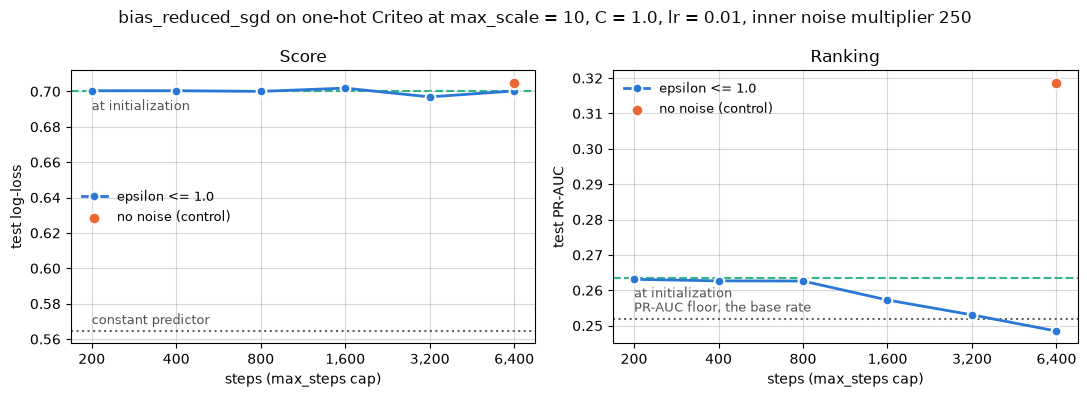

In [15]:
losses = [o.average.loss for o in curve]
aucs = [o.average.pr_auc for o in curve]

fig, (left, right) = plt.subplots(1, 2, figsize=(11, 4))

left.plot(STEP_GRID, losses, marker="o", markersize=7, linewidth=2,
          color=PRIVATE_C, markeredgecolor=SURFACE, markeredgewidth=1.5,
          label=f"epsilon <= {TARGET_EPSILON}", zorder=3)
left.scatter([STEP_GRID[-1]], [control.average.loss], s=70, zorder=3,
             color=CONTROL_C, edgecolor=SURFACE, linewidth=1.5,
             label="no noise (control)")
left.axhline(CONST.loss, color=MUTED, linestyle=":", alpha=0.9)
left.annotate("constant predictor", xy=(STEP_GRID[0], CONST.loss),
              xytext=(0, 5), textcoords="offset points", color=MUTED,
              fontsize=9)
left.axhline(BEFORE.loss, color=THIRD_C, linestyle="--", alpha=0.9)
left.annotate("at initialization", xy=(STEP_GRID[0], BEFORE.loss),
              xytext=(0, -14), textcoords="offset points", color=MUTED,
              fontsize=9)
left.set_ylabel("test log-loss")
left.set_title("Score")

right.plot(STEP_GRID, aucs, marker="o", markersize=7, linewidth=2,
           color=PRIVATE_C, markeredgecolor=SURFACE, markeredgewidth=1.5,
           label=f"epsilon <= {TARGET_EPSILON}", zorder=3)
right.scatter([STEP_GRID[-1]], [control.average.pr_auc], s=70, zorder=3,
              color=CONTROL_C, edgecolor=SURFACE, linewidth=1.5,
              label="no noise (control)")
right.axhline(base_rate, color=MUTED, linestyle=":", alpha=0.9)
right.annotate("PR-AUC floor, the base rate", xy=(STEP_GRID[0], base_rate),
               xytext=(0, 5), textcoords="offset points", color=MUTED,
               fontsize=9)
right.axhline(BEFORE.pr_auc, color=THIRD_C, linestyle="--", alpha=0.9)
right.annotate("at initialization", xy=(STEP_GRID[0], BEFORE.pr_auc),
               xytext=(0, -14), textcoords="offset points", color=MUTED,
               fontsize=9)
right.set_ylabel("test PR-AUC")
right.set_title("Ranking")

for axis, where in ((left, "center left"), (right, "upper left")):
    axis.set_xlabel("steps (max_steps cap)")
    axis.set_xscale("log")
    axis.set_xticks(list(STEP_GRID))
    axis.set_xticklabels([f"{steps:,}" for steps in STEP_GRID])
    axis.minorticks_off()
    axis.grid(alpha=0.5)
    axis.legend(loc=where, frameon=False, fontsize=9)

fig.suptitle(f"bias_reduced_sgd on one-hot Criteo at max_scale = "
             f"{BEST_SCALE}, C = {BEST_C}, lr = {BEST_LR}, inner noise "
             f"multiplier {multiplier:.0f}", color=INK)
fig.tight_layout()
plt.show()

### Reading those two panels

**The score does not move and the ranking gets worse.** Log-loss sits between
0.6969 and 0.7019 across a thirty-twofold range of run lengths and never
approaches the constant predictor's 0.5645 — the flat line in the left panel
is the whole result. The right panel is the one with a trend, and it points
down: PR-AUC falls 0.2631 → 0.2485 from 200 steps to 6,400 and crosses below
the base-rate floor of 0.2520 somewhere past 3,200. The run is not converging
slowly; it is walking away from its initialization in a direction that ranks
worse than random.

**ε confirms how little was spent.** The longest run charges 0.0090 against a
budget of 1, because 6,400 steps is 7% of the 94,073 the filter would admit
at this `max_scale`. The cap costs utility and never privacy — and it did not
make the steps any quieter, since the multiplier is fixed by the budget.
Section 8 is where the missing 93,600 steps are priced.

**The control says the loop is not what is broken.** With the noise switched
off and everything else identical, the same 6,400 steps lift PR-AUC to 0.3187
for `x̄` and 0.3623 for the last iterate, well clear of the 0.2520 floor. The
draws, the clipping, the ℓ₁ projection, the debias combine, the sparse
encoding and the model all work; the perturbation is what erases the result.

The control is badly calibrated while it does that — calibration ratio 3.39
on `x̄` and 3.90 on the last iterate, and at the base-rate threshold that last
iterate flags three records out of 200,000 — and that is a second, quieter
finding rather than a defect in it.
`C = 1.0` and `lr = 0.01` were selected in section 6 from runs in which
nothing was learning, so they are not the settings a working run would have
asked for. A sweep whose rows are all noise cannot recommend anything, and
this is what that looks like once the noise is taken away.

## 8. Why: the ratio the mechanism has to work against

The sections above report that nothing moved. This one measures why, and the
measurement is about the mechanism rather than about the tuning.

One inner release perturbs a mean of ℓ₂ sensitivity `2C/k` at noise
multiplier 250, so each of the 551,947 coordinates receives Gaussian noise of
scale `250 · 2C / k`. Set that beside the mean gradient the release is trying
to report — computed below over a sample of the training set, at the
initialization, after the same clipping. The projection onto the ℓ₁ ball is
what stands between the two, and Lemma 3.1 is why it helps at all: it is the
sparsity of the target, not the size of the batch, that lets a ball of radius
`C√40` recover something from a cloud of 551,947 noisy coordinates.

In [16]:
CHUNK = 2_048
probe_rows = np.asarray(jax.random.choice(
    jax.random.key(2), n_train, (32 * CHUNK,), replace=False))


@jax.jit
def clipped_sum(params, x_chunk, y_chunk):
    """The sum of clipped per-sample gradients over one chunk.

    Chunked because the whole sample at once is the dense block section 3
    is about: 65,536 rows would be 145 GB.
    """
    clipped = clipping.per_sample_clip(
        PER_SAMPLE_GRADS(params, x_chunk, y_chunk), BEST_C)
    return jax.tree.map(lambda leaf: leaf.sum(0), clipped)


total = None
for start in range(0, len(probe_rows), CHUNK):
    rows = probe_rows[start:start + CHUNK]
    part = clipped_sum(START, X_TRAIN[rows], split.y_train[rows])
    total = part if total is None else jax.tree.map(jnp.add, total, part)
target = jax.tree.map(
    lambda leaf: np.asarray(leaf, np.float64) / len(probe_rows), total)
target_flat = np.concatenate([np.ravel(target["w"]), np.ravel(target["b"])])
target_l2 = float(np.linalg.norm(target_flat))

largest_coordinate = np.abs(target_flat).max()
print(f"the mean clipped gradient at the initialization, over "
      f"{len(probe_rows):,} rows and C = {BEST_C}:")
print(f"  l2 {target_l2:.4f}   l1 {np.abs(target_flat).sum():.4f} "
      f"(the radius is {BEST_C * np.sqrt(SPARSITY):.2f})   "
      f"largest coordinate {largest_coordinate:.4f}   "
      f"nonzero {int((target_flat != 0).sum()):,} of {len(target_flat):,}\n")

def release_noise_scale(batch_size):
    """The Gaussian scale one inner release puts on one coordinate.

    ``noise_multiplier`` times the sensitivity ``2 * clip_norm / k`` of
    the mean it perturbs. Takes an array as readily as a number.
    """
    return multiplier * 2 * BEST_C / batch_size


ladder_law = dyadic.scale_probabilities(BEST_SCALE)
print(f"{'scale':>5} {'batch':>7} {'p_N':>9} {'noise scale':>12} "
      f"{'vs largest coordinate':>22}")
for scale in range(BEST_SCALE + 1):
    size = 1 << (scale + 1)
    noise_scale = release_noise_scale(size)
    print(f"{scale:>5} {size:>7,} {ladder_law[scale]:>9.5f} "
          f"{noise_scale:>12.2f} "
          f"{noise_scale / largest_coordinate:>21,.0f}x")

the mean clipped gradient at the initialization, over 65,536 rows and C = 1.0:
  l2 0.2335   l1 2.8606 (the radius is 6.32)   largest coordinate 0.0947   nonzero 124,150 of 551,948

scale   batch       p_N  noise scale  vs largest coordinate
    0       2   0.50024       250.45                 2,645x
    1       4   0.25012       125.22                 1,323x
    2       8   0.12506        62.61                   661x
    3      16   0.06253        31.31                   331x
    4      32   0.03127        15.65                   165x
    5      64   0.01563         7.83                    83x
    6     128   0.00782         3.91                    41x
    7     256   0.00391         1.96                    21x
    8     512   0.00195         0.98                    10x
    9   1,024   0.00098         0.49                     5x
   10   2,048   0.00049         0.24                     3x


Those are the coordinates going in. What comes out is one debiased estimate
`G`, and the question the loop actually depends on is how it sits against the
target: an estimator whose error is unbiased noise is rescued by averaging,
at `sqrt(T)`, while a projection that returns the wrong vector is not
rescued by anything.

The probe below draws scales from the same coin the loop uses, runs the same
two releases through `step.batch_release` and `step.single_release`, and
combines them with `step.debiased_gradient` — the package's own step, not a
reimplementation of it — at the initialization, where the target above was
computed. It reports the average estimate against the target, the typical
error of a single estimate, and the number of steps that error implies.

In [17]:
probe_estimator = estimators.projection_estimator(
    clip_norm=BEST_C, radius=BEST_C * np.sqrt(SPARSITY),
    noise_multiplier=multiplier,
)
batch_call = partial(brs_step.batch_release, PER_SAMPLE_GRADS,
                     probe_estimator)
single_call = partial(brs_step.single_release, PER_SAMPLE_GRADS,
                      probe_estimator)
releases = brs_step.Releases(
    batch=jax.jit(batch_call, static_argnames=("batch_size",)),
    single=jax.jit(single_call),
)
scale_law = dyadic.scale_probabilities(BEST_SCALE)
probe_rng = np.random.default_rng(SEED)
probe_key = jax.random.key(SEED)

running, squared_error = None, 0.0
t0 = time.time()
for _ in range(PROBE_DRAWS):
    scale = dyadic.draw_scale(probe_rng, BEST_SCALE)
    draw = dyadic.subsample(probe_rng, n_train, scale)
    probe_key, batch_key, single_key = jax.random.split(probe_key, 3)
    batch = releases.batch(START, X_TRAIN[draw.whole],
                           split.y_train[draw.whole], batch_key,
                           batch_size=1 << (scale + 1))
    single = releases.single(START, X_TRAIN[draw.single],
                             split.y_train[draw.single], single_key)
    estimate = brs_step.debiased_gradient(
        batch, single, scale_probability=float(scale_law[scale])
    )
    flat = np.concatenate([np.ravel(estimate["w"]), np.ravel(estimate["b"])])
    squared_error += float(np.sum((flat - target_flat) ** 2))
    running = flat if running is None else running + flat

mean_estimate = running / PROBE_DRAWS
error_rms = np.sqrt(squared_error / PROBE_DRAWS)
steps_for_parity = (error_rms / target_l2) ** 2

print(f"{PROBE_DRAWS} debiased estimates at the initialization, "
      f"{time.time() - t0:.0f}s\n")
print(f"  the target                 l2 {target_l2:.4f}")
print(f"  one estimate               rms error {error_rms:,.1f}, "
      f"{error_rms / target_l2:,.0f}x the target's own length")
print(f"  their mean                 l2 {np.linalg.norm(mean_estimate):.4f}, "
      f"against a noise floor of {error_rms / np.sqrt(PROBE_DRAWS):,.1f} — "
      f"so this average is not yet a measurement of anything but the noise\n")
print(f"  the sum of T estimates carries T * target against "
      f"sqrt(T) * {error_rms:,.0f}, so the accumulated step reaches parity "
      f"with its own noise at T = {steps_for_parity:,.0f}")
admitted = filter_length(BEST_SCALE).delta_arm
print(f"  the filter admits about {admitted:,.0f} steps, "
      f"{steps_for_parity / admitted:.1f}x short of it")

512 debiased estimates at the initialization, 18s

  the target                 l2 0.2335
  one estimate               rms error 193.3, 828x the target's own length
  their mean                 l2 8.5440, against a noise floor of 8.5 — so this average is not yet a measurement of anything but the noise

  the sum of T estimates carries T * target against sqrt(T) * 193, so the accumulated step reaches parity with its own noise at T = 685,401
  the filter admits about 94,073 steps, 7.3x short of it


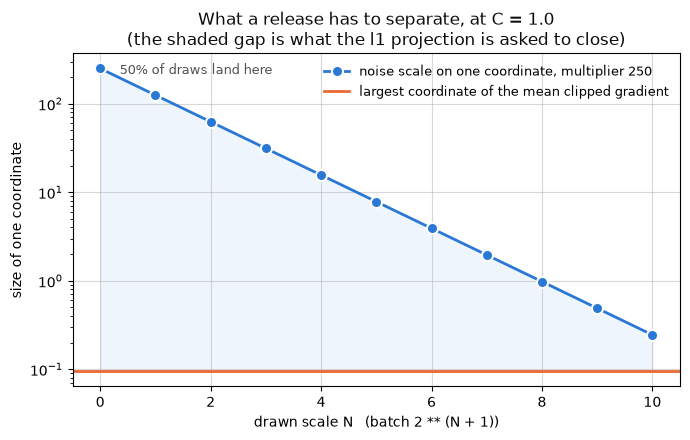

In [18]:
scales = np.arange(BEST_SCALE + 1)
noise_scales = release_noise_scale(2.0 ** (scales + 1))

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(scales, noise_scales, marker="o", markersize=8, linewidth=2,
        color=PRIVATE_C, markeredgecolor=SURFACE, markeredgewidth=1.5,
        label=f"noise scale on one coordinate, multiplier {multiplier:.0f}")
ax.axhline(largest_coordinate, color=CONTROL_C, linewidth=2,
           label="largest coordinate of the mean clipped gradient")
ax.fill_between(scales, largest_coordinate, noise_scales,
                color=PRIVATE_C, alpha=0.07)
ax.annotate(f"{scale_law[0]:.0%} of draws land here",
            xy=(0, noise_scales[0]), xytext=(14, -4),
            textcoords="offset points", color=MUTED, fontsize=9)
ax.set_yscale("log")
ax.set_xlabel("drawn scale N   (batch 2 ** (N + 1))")
ax.set_ylabel("size of one coordinate")
ax.set_title(f"What a release has to separate, at C = {BEST_C}\n"
             f"(the shaded gap is what the l1 projection is asked to close)",
             color=INK)
ax.grid(alpha=0.5)
ax.legend(loc="upper right", frameon=False, fontsize=9)
fig.tight_layout()
plt.show()

### Reading the ratio

**The gap the projection is asked to close is three orders of magnitude, at
the scales that are actually drawn.** Half of all draws land at `N = 0`,
where the batch is two examples and each of the 551,947 coordinates receives
noise of scale 250 against a largest true coordinate of 0.095 — a factor of
2,645. Each rung of the ladder halves the gap, and the ladder runs out before
the gap does: at the top of this mechanism, `N = 10` with a batch of 2,048,
the noise is still three times the largest coordinate of the thing being
measured, and one draw in two thousand lands there.

**What comes out is 828 times the length of what went in.** That is the
number the notebook turns on: the root-mean-square error of one debiased
estimate is 193 against a mean gradient of length 0.2335. Error alone is not
a reason to give up — it is noise, and the sum of `T` steps carries `T` times
the signal against `sqrt(T)` times the error — but the arithmetic then gives
a price. Parity needs `T = 685,401` steps and the filter admits 94,073, so
**the run is 7.3 times too short at the largest budget Lemma 5.3 covers.** No
setting of `max_steps` reaches it, because `max_steps` only makes runs
shorter, and no larger ε is available, because `train` refuses one.

Two caveats on the probe. It is taken at the initialization, and the mean
gradient shrinks as a model fits, so the ratio is a lower bound on the
difficulty rather than a constant of the problem. And the average of 512
estimates has a noise floor of 8.5, which is its own length — so this cell
says nothing about whether the estimator is unbiased. It measures how big the
error is, which is what the `sqrt(T)` argument needs and all that it needs.

## What this shows, and what it does not

`bias_reduced_sgd` end to end on 800,000 real Criteo rows and 551,947 one-hot
coordinates, at the algorithm's own maximum budget of ε = 1 with δ = 1e-12,
swept over all three of its knobs: `max_scale` across six mechanisms, the
clipping norm against the learning rate across nine configurations, and the
selected configuration across six run lengths. Twenty-one private runs and
one control, executed in eight minutes on one RTX 6000 Ada.

**Nothing was learned, and knowing why is the result.** The selected
configuration — `max_scale = 10`, `C = 1.0`, radius 6.32, `lr = 0.01`, inner
noise multiplier 250, mean batch 11 — reaches test log-loss 0.7002 at 6,400
steps against the initialization's 0.7004 and the constant predictor's
0.5645, and PR-AUC 0.2485 against a base-rate floor of 0.2520. At the
base-rate threshold it catches 48,631 of the 50,400 test clicks and raises
143,638 false alarms, which is very nearly the everything-is-a-click answer a
model with logits at zero gives. The accountant reports ε = 0.0090 for that
transcript; the guarantee the run carries is (1, 1e-12).

The reason is arithmetic rather than tuning. Each inner release perturbs a
mean of ℓ₂ sensitivity `2C/k` at a multiplier of 250, so one debiased
estimate has an error 828 times the length of the gradient it estimates;
averaging beats that at `sqrt(T)` and so needs about 685,000 steps, while the
privacy filter admits about 94,000. The same loop with the perturbation
switched off ranks at PR-AUC 0.3187 on `x̄` and 0.3623 on its last iterate, so
the encoding, the model, the draws, the projection and the debias combine are
all doing their jobs.

**The frozen operating point is a coin toss, and a comparison notebook
inheriting it should repeat that.** Log-loss is notebook 01's selection rule
and this notebook kept it, but it names a row with the worst PR-AUC of its
clip column — 0.2538 against 0.2637 — so the ranking convention Criteo runs
under would have frozen something else. At a multiplier of 250 the nine rows
differ by less than a single seed's noise, which is why the disagreement
cannot be settled from this table and why the point below is offered as
"which of these nine", not as "what would train this model".

Not shown, and not claimed:

- **This is not a verdict on the method.** It is a verdict on this method at
  ε ≤ 1 on this problem: 551,947 coordinates, a 40-sparse gradient, and a
  filter that stops after about 94,000 steps. The paper's regime wants `s`
  small against `d` — which holds here, by construction — *and* enough steps
  for the estimate to average, which does not.
- **`max_steps` capped every run**, at 3,000 in the two sweeps and 6,400 in
  the last: 3% and 7% of what the filter would admit. That costs utility and
  never privacy, but it means the tables compare configurations at a length
  none of them was designed for. Section 8's arithmetic is the reason the
  notebook does not expect the uncapped run to come out differently, and it
  is an argument rather than a measurement.
- **The budget is δ = 1e-12, not the δ = 1e-3 issue #44 sketched.** Section 2
  pays the package's `δ < 1 / n ** 2` precondition because section 8's whole
  argument is a step-count argument, and the price is a multiplier of 250
  rather than 142 — 1.8 times the noise. Scaling section 8's numbers by that
  ratio, the ticket's δ would give an estimate error near 470 times the
  signal and parity near 220,000 steps against the same 94,000 the filter
  admits, since the δ arm's length is independent of δ. Still short by more
  than a factor of two, and that is arithmetic rather than a run.
- **One seed.** Every run is `seed=0`, and section 7's six lengths share it,
  so no gap comes with an error bar and the step curve is one trajectory
  rather than six.
- **The search is unaccounted, and all twenty-one private runs were scored on
  the test split** — the fifteen configurations of the two sweeps and the six
  lengths of the last — with the reported configuration picked from among
  them. The figures are optimistic as held-out estimates as well as unpaid
  for as a privacy matter.
- **The preprocessing statistics are unaccounted** (ADR-0008). The vocabulary
  and the medians are fitted on the training split; the ε above covers the
  training loop only.
- **The amplification is the paper's, not dimma's.** Lemma 5.3 amplifies a
  fixed-size draw *without* replacement, which is not the Poisson statement
  `accounting.sampling` wraps; `accounting.bias_reduced_sgd`'s module
  docstring records that and the three other things it cannot check.
- **The control is not a private run.** It reaches through the `estimator`
  seam to switch the perturbation off, and the ε its accountant would print
  is the price of a mechanism that did not run.
- **The operating point is a choice.** Every confusion matrix thresholds at
  the training base rate; a different cut gives different precision and
  recall from the same model, while the ranking does not move.
- **The ε here is a filter's** (ADR-0018), which is advanced composition over
  an adaptively chosen schedule. A Rényi filter would be tighter and is
  ticketed as #35; it would buy more steps at the same budget, and section 8
  says how many more would be needed.